#  Rainfall Prediction using Machine Learning

In this notebook, we build models to predict annual rainfall using historical data.

The goal is to develop a **realistic and interpretable model**.

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from google.colab import drive
drive.mount('/content/drive')
file_path = "/content/drive/MyDrive/cleaned_rainfall.csv"
df = pd.read_csv(file_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df['prev_year'] = df.groupby('region')['annual'].shift(1)
df = df.dropna()

### Addressing Data Leakage

Considering every feature for modeling shows extremely high accuracy due to the inclusion of monthly rainfall features, which directly sum to annual rainfall.

This results in data leakage.

To correct this, the model is retrained using previous year rainfall (temporal feature) only.


This ensures that predictions are meaningful and realistic.

In [ ]:
all_features = [
    'jan','feb','mar','apr','may',
    'jun','jul','aug','sep','oct','nov','dec',
    'winter','summer','monsoon','post_monsoon',
    'prev_year'
]
feature = ['prev_year']
X1 = df[feature]
y1 = df['annual']
X2 = df[all_features]
y2 = df['annual']

In [ ]:
X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.2, random_state=42
)
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

In [ ]:
lr = LinearRegression()
lr.fit(X1_train, y1_train)

y1_pred_lr = lr.predict(X1_test)

In [ ]:
lr = LinearRegression()
lr.fit(X2_train, y2_train)

y2_pred_lr = lr.predict(X2_test)

In [ ]:
rmse_lr = np.sqrt(mean_squared_error(y2_test, y2_pred_lr))
r2_lr = r2_score(y2_test, y2_pred_lr)

print("Linear Regression RMSE:", rmse_lr)
print("Linear Regression R2:", r2_lr)

Linear Regression RMSE: 111.2411610854796
Linear Regression R2: 0.9860913923976014


In [ ]:
rmse_lr = np.sqrt(mean_squared_error(y1_test, y1_pred_lr))
r2_lr = r2_score(y1_test, y1_pred_lr)

print("Linear Regression RMSE:", rmse_lr)
print("Linear Regression R2:", r2_lr)

Linear Regression RMSE: 377.84504710827923
Linear Regression R2: 0.8395350829872148


In [ ]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X1_train, y1_train)

y1_pred_rf = rf.predict(X1_test)

In [ ]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X2_train, y2_train)

y2_pred_rf = rf.predict(X2_test)

In [ ]:
rmse_rf = np.sqrt(mean_squared_error(y2_test, y2_pred_rf))
r2_rf = r2_score(y2_test, y2_pred_rf)

print("Random Forest RMSE:", rmse_rf)
print("Random Forest R2:", r2_rf)

Random Forest RMSE: 142.8649820182967
Random Forest R2: 0.977059429706758


In [ ]:
rmse_rf = np.sqrt(mean_squared_error(y1_test, y1_pred_rf))
r2_rf = r2_score(y1_test, y1_pred_rf)

print("Random Forest RMSE:", rmse_rf)
print("Random Forest R2:", r2_rf)

Random Forest RMSE: 429.43991575341806
Random Forest R2: 0.7927199779077571


In [ ]:
print("Linear Regression R2:", r2_lr)
print("Random Forest R2:", r2_rf)

Linear Regression R2: 0.8395350829872148
Random Forest R2: 0.7927199779077571


### Model Performance

The model achieves an R² of approximately 0.84 when using previous year rainfall.

This indicates a strong temporal dependency, while still leaving room for unexplained variability.

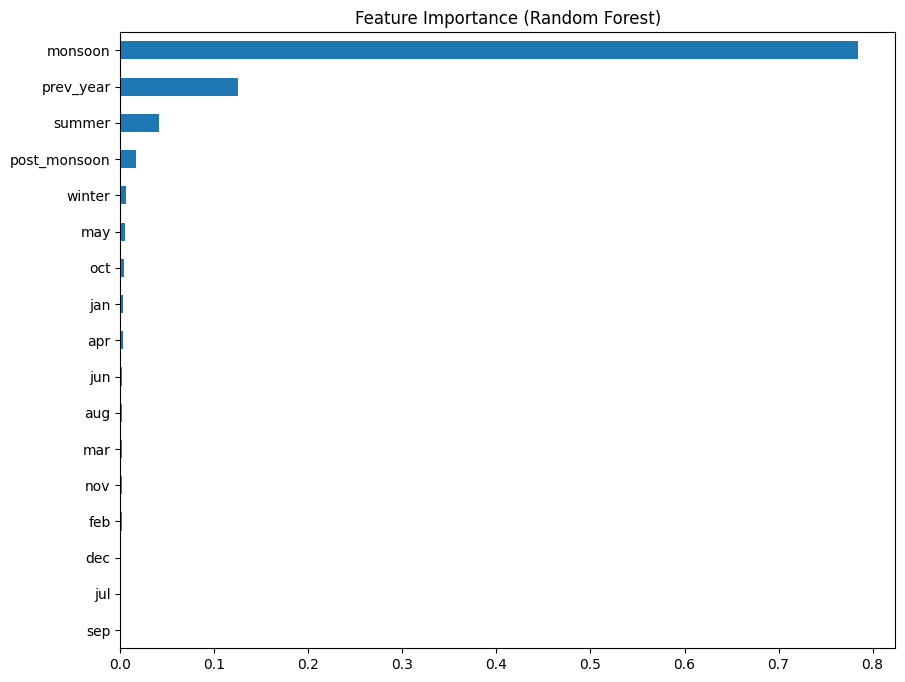

In [ ]:
import matplotlib.pyplot as plt

importance = pd.Series(rf.feature_importances_, index=X2.columns)
importance.sort_values().plot(kind='barh', figsize=(10,8))

plt.title("Feature Importance (Random Forest)")
plt.show()

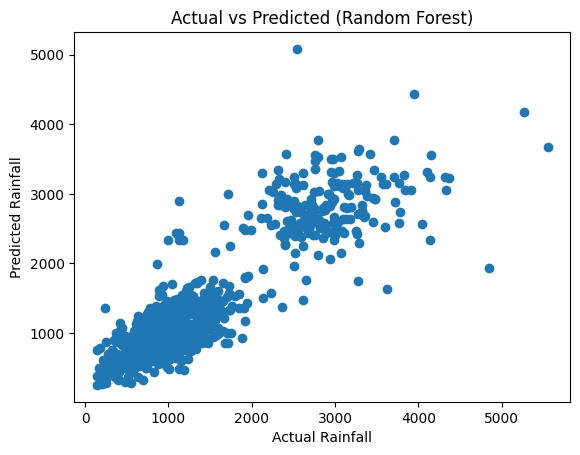

In [ ]:
plt.scatter(y1_test, y1_pred_rf)
plt.xlabel("Actual Rainfall")
plt.ylabel("Predicted Rainfall")
plt.title("Actual vs Predicted (Random Forest)")
plt.show()

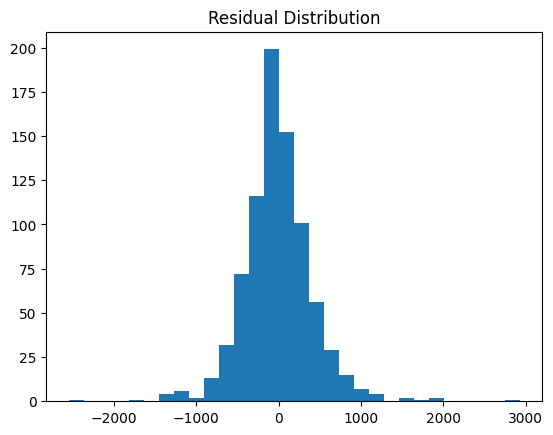

In [ ]:
residuals = y1_test - y1_pred_rf

plt.hist(residuals, bins=30)
plt.title("Residual Distribution")
plt.show()

### Interpretation

The results suggest that rainfall exhibits persistence over time, but cannot be fully explained by historical values alone.

This highlights the influence of additional climatic factors not included in the model.